In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import raytrace as rt
import math
from pylab import *
from raytrace import implane
import rtcore

/home/hp/miniconda3/envs/py27/lib/python2.7/site-packages/pyfits/__init__.py:22: PyFITSDeprecationWarning: PyFITS is deprecated, please use astropy.io.fits
  PyFITSDeprecationWarning)  # noqa


In [2]:
# =====================================================
# PARAMETERS
# =====================================================
freq_list = [10.e6, 18.e6, 40.e6, 80.e6, 200.e6, 3000.e6]  # Hz
z_heights = [0.18, 0.67]   # solar radii
grid = (100, 100)
rect = (-1, -1, 1, 1)
obs = (215, 0, 0)   # Observer position in SGI system (Earth)
rsph = 10           # Radius of the integration sphere
niter = 1500        # Maximum iterations

# Output path
out_dir  = '/home/hp/raytrace_work/raytrace_results/Ray_Trajectories_frequency_band'
out_file = os.path.join(out_dir, 'Ray_Trajectories_frequency_band.png')

if not os.path.exists(out_dir):
    os.makedirs(out_dir)

# =====================================================
# IMAGE PLANE GRID
# =====================================================
nx = int(grid[0])
ny = int(grid[1])

ymin, ymax = -1.0, 1.0
zmin, zmax = -1.0, 1.0
y = np.linspace(ymin, ymax, nx)
z = np.linspace(zmin, zmax, ny)

# Choose Y ~ 0
iy = np.argmin(np.abs(y - 0.0))
print 'Chosen Y index:', iy

Chosen Y index: 49


Running freq = 10.0 MHz at Z = 0.18
plf_cname =  plasma_parameters.c
fname =  plasma_parameters.c
dname =  /home/hp/raytrace_work/raytrace_scripts
bfname =  plasma_parameters.c
name =  plasma_parameters
gcc -g -fPIC  -I/home/hp/miniconda3/envs/py27/lib/python2.7/site-packages/raytrace/inc -c /home/hp/raytrace_work/raytrace_scripts/streamer.c -o streamer.o
gcc -g -fPIC  -I/home/hp/miniconda3/envs/py27/lib/python2.7/site-packages/raytrace/inc -c plasma_parameters.c -o plasma_parameters.o
gcc -shared streamer.o plasma_parameters.o -L/home/hp/miniconda3/envs/py27/lib/python2.7/site-packages/raytrace/lib -L/usr/lib -lm -lmxv -o plasma_parameters.so
Running freq = 18.0 MHz at Z = 0.18
plf_cname =  plasma_parameters.c
fname =  plasma_parameters.c
dname =  /home/hp/raytrace_work/raytrace_scripts
bfname =  plasma_parameters.c
name =  plasma_parameters
gcc -g -fPIC  -I/home/hp/miniconda3/envs/py27/lib/python2.7/site-packages/raytrace/inc -c /home/hp/raytrace_work/raytrace_scripts/streamer.c -o s

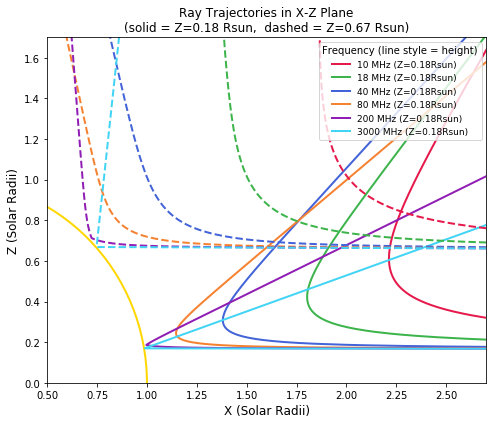

In [3]:
# =====================================================
# FIGURE SETUP
# =====================================================
fig = plt.figure(figsize=(7, 6))
ax  = fig.add_subplot(111)

# Color cycle - one colour per frequency
colors = ['#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4', '#42d4f4']

# Line style - one per z_height
styles = {z_heights[0]: '-', z_heights[1]: '--'}

# =====================================================
# TRACE RAYS AND PLOT
# =====================================================
for z0 in z_heights:
    iz = np.argmin(np.abs(z - z0))
    trkrays = [[iy, iz]]

    for idx, freq_hz in enumerate(freq_list):
        print 'Running freq =', freq_hz/1.e6, 'MHz at Z =', z0

        test1 = rt.implane(grid,
                           rect,
                           obs,
                           rsph,
                           freq=freq_hz,
                           mode='TbrIQUV',
                           trkparms=['pos'],
                           trknpmax=1500)
        test1.package = '/home/hp/raytrace/py_raytr_threaded'
        test1.trace(niter, trkrays)

        traj = test1.traj.pos  # shape: (1, nsteps, 3)

        # ── ASCII save ──
        fname = 'traj_Z%.2f_F%.0fMHz.txt' % (z0, freq_hz/1.e6)
        np.savetxt(fname,
                   np.column_stack((traj[0,:,0], traj[0,:,1], traj[0,:,2])),
                   header='X Y Z')

        # ── Plot directly ──
        ax.plot(traj[0, :, 0],
                traj[0, :, 2],
                linestyle=styles[z0],
                linewidth=2,
                color=colors[idx],
                label='%.0f MHz (Z=%.2fRsun)' % (freq_hz/1.e6, z0))
    
# =====================================================
# DRAW SOLAR DISC
# =====================================================
sun = plt.Circle((0.0, 0.0), 1.0, fill=False, linewidth=2, color='gold')
ax.add_patch(sun)

# =====================================================
# AXES, LABELS, LEGEND
# =====================================================
ax.set_xlabel('X (Solar Radii)', fontsize=12)
ax.set_ylabel('Z (Solar Radii)', fontsize=12)
ax.set_title('Ray Trajectories in X-Z Plane\n'
             '(solid = Z=0.18 Rsun,  dashed = Z=0.67 Rsun)',
             fontsize=12)
ax.set_xlim(0.5, 2.7)
ax.set_ylim(0.0, 1.7)

# Deduplicate legend - one entry per frequency, not per z_height
handles, labels = ax.get_legend_handles_labels()
seen = {}
unique_handles = []
unique_labels  = []
for h, l in zip(handles, labels):
    freq_key = l.split(' ')[0]      # e.g. "10"
    if freq_key not in seen:
        seen[freq_key] = True
        unique_handles.append(h)
        unique_labels.append(l)

ax.legend(unique_handles, unique_labels,
          loc='upper right', fontsize=9,
          title='Frequency (line style = height)')

plt.tight_layout()

# =====================================================
# SAVE FIGURE
# =====================================================
fig.savefig(out_file, dpi=150, bbox_inches='tight')
print 'Saved figure:', out_file

plt.show()